# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

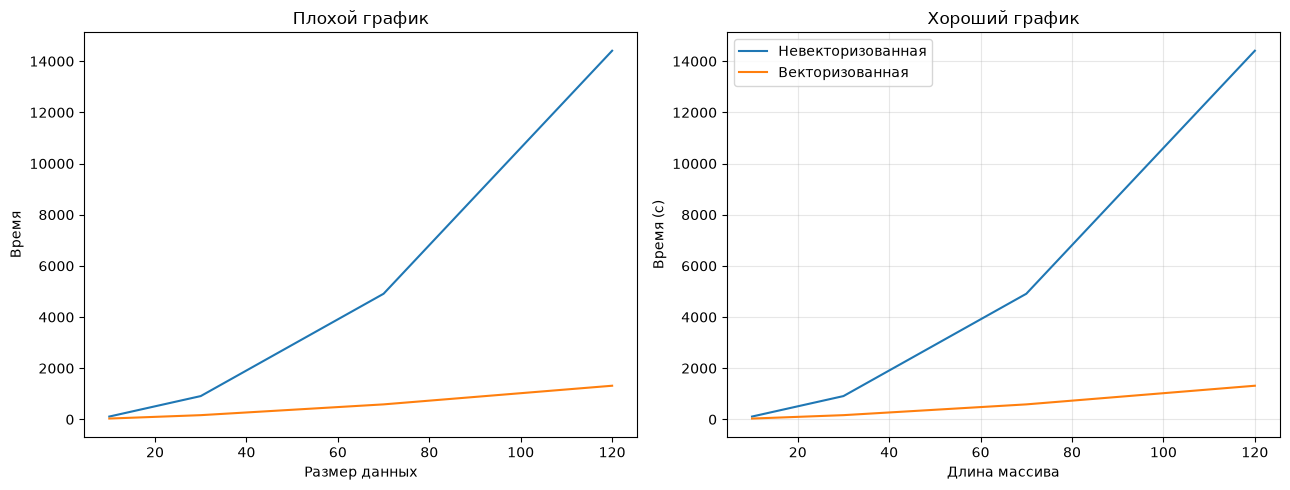

In [2]:
from importlib import reload
from PIL import Image
from scipy.spatial.distance import cdist

import timeit
import matplotlib.pyplot as plt
import numpy as np

import functions as func
import functions_vectorized as func_vec

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(func)
    reload(func_vec)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

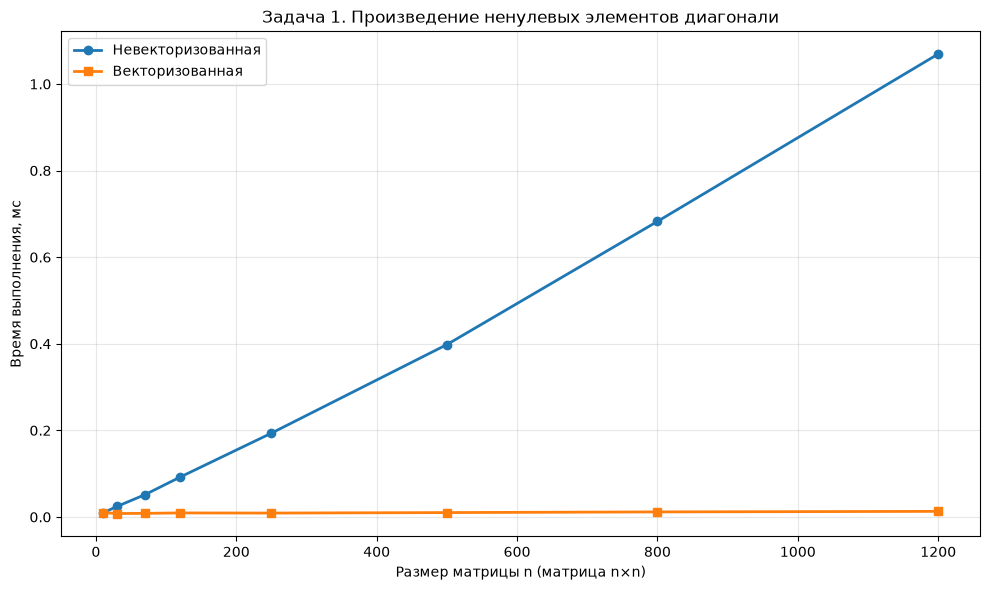

In [3]:
reload_solution_modules()
# code here

data_size = np.array([10, 30, 70, 120, 250, 500, 800, 1200])
rng = np.random.default_rng(2101)

n_runs = 100
n_repeats = 7

time_func = []
time_func_vec = []

for n in data_size:
    x = rng.integers(0, 100, size = (n, n), dtype = np.int64)

    cur_time_func = min(
        timeit.repeat(
            lambda: func.prod_non_zero_diag(x),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_func_vec = min(
        timeit.repeat(
            lambda: func_vec.prod_non_zero_diag(x),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    time_func.append(cur_time_func)
    time_func_vec.append(cur_time_func_vec)

plt.figure(figsize=(10, 6))

plt.plot(data_size, time_func,
         marker="o",
         linewidth=2,
         label="Невекторизованная")

plt.plot(data_size, time_func_vec,
         marker="s",
         linewidth=2,
         label="Векторизованная")

plt.title("Задача 1. Произведение ненулевых элементов диагонали")
plt.xlabel("Размер матрицы n (матрица n×n)")
plt.ylabel("Время выполнения, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  



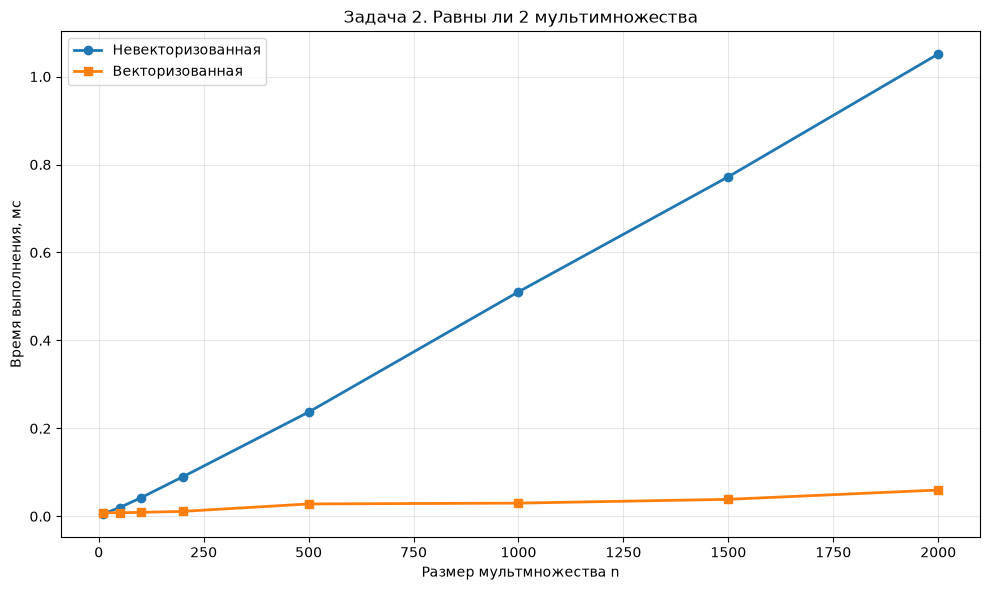

In [4]:
reload_solution_modules()
# code here

data_size = np.array([10, 50, 100, 200, 500, 1000, 1500, 2000])
rng = np.random.default_rng(2101)

n_runs = 100
n_repeats = 7

time_func = []
time_func_vec = []

for n in data_size:
    x = rng.integers(0, 100, size = (n), dtype = np.int64)
    y = rng.integers(0, 100, size = (n), dtype = np.int64)

    cur_time_func = min(
        timeit.repeat(
            lambda: func.are_multisets_equal(x, y),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_func_vec = min(
        timeit.repeat(
            lambda: func_vec.are_multisets_equal(x, y),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    time_func.append(cur_time_func)
    time_func_vec.append(cur_time_func_vec)

plt.figure(figsize=(10, 6))

plt.plot(data_size, time_func,
         marker="o",
         linewidth=2,
         label="Невекторизованная")

plt.plot(data_size, time_func_vec,
         marker="s",
         linewidth=2,
         label="Векторизованная")

plt.title("Задача 2. Равны ли 2 мультимножества")
plt.xlabel("Размер мультмножества n")
plt.ylabel("Время выполнения, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

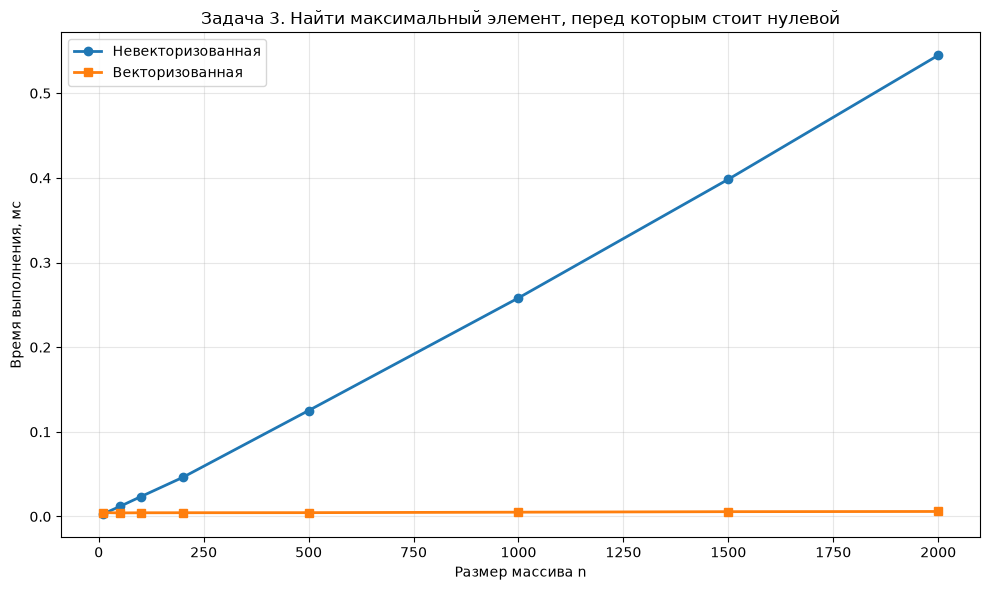

In [5]:
reload_solution_modules()
# code here

data_size = np.array([10, 50, 100, 200, 500, 1000, 1500, 2000])
rng = np.random.default_rng(2101)

n_runs = 100
n_repeats = 7

time_func = []
time_func_vec = []

for n in data_size:
    x = rng.integers(0, 100, size = (n), dtype = np.int64)
    x[0] = 0

    cur_time_func = min(
        timeit.repeat(
            lambda: func.max_after_zero(x),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_func_vec = min(
        timeit.repeat(
            lambda: func_vec.max_after_zero(x),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    time_func.append(cur_time_func)
    time_func_vec.append(cur_time_func_vec)

plt.figure(figsize=(10, 6))

plt.plot(data_size, time_func,
         marker="o",
         linewidth=2,
         label="Невекторизованная")

plt.plot(data_size, time_func_vec,
         marker="s",
         linewidth=2,
         label="Векторизованная")

plt.title("Задача 3. Найти максимальный элемент, перед которым стоит нулевой")
plt.xlabel("Размер массива n")
plt.ylabel("Время выполнения, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


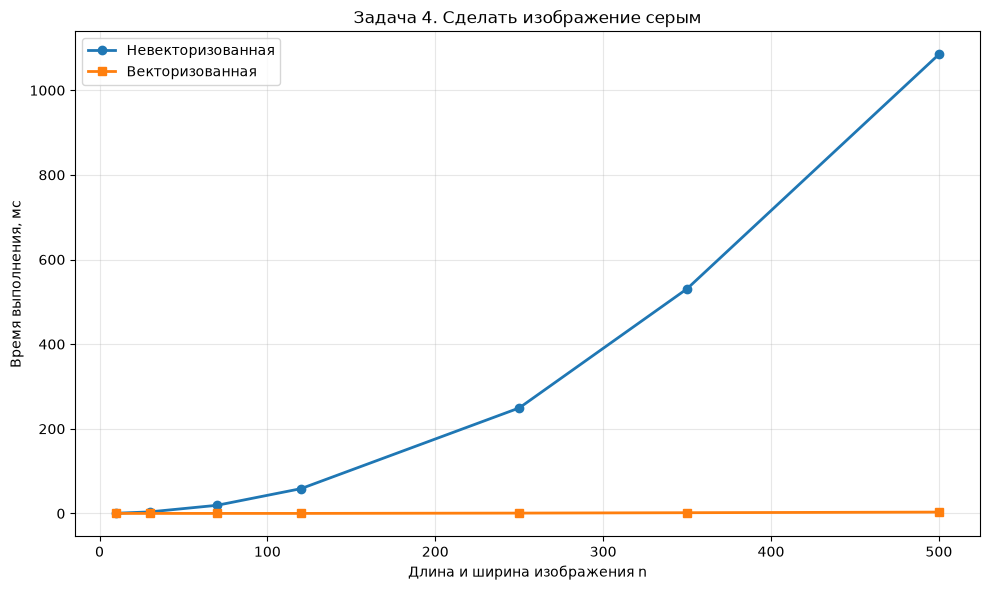

In [6]:
reload_solution_modules()
# code here

data_size = np.array([10, 30, 70, 120, 250, 350, 500])
rng = np.random.default_rng(2101)

coefs = np.array([0.299, 0.587, 0.114])

n_runs = 5
n_repeats = 5

time_func = []
time_func_vec = []

for n in data_size:
    img = rng.integers(0, 256, size = (n, n, 3), dtype = np.int64)

    cur_time_func = min(
        timeit.repeat(
            lambda: func.convert_image(img, coefs),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_func_vec = min(
        timeit.repeat(
            lambda: func_vec.convert_image(img, coefs),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    time_func.append(cur_time_func)
    time_func_vec.append(cur_time_func_vec)

plt.figure(figsize=(10, 6))

plt.plot(data_size, time_func,
         marker="o",
         linewidth=2,
         label="Невекторизованная")

plt.plot(data_size, time_func_vec,
         marker="s",
         linewidth=2,
         label="Векторизованная")

plt.title("Задача 4. Сделать изображение серым")
plt.xlabel("Длина и ширина изображения n")
plt.ylabel("Время выполнения, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

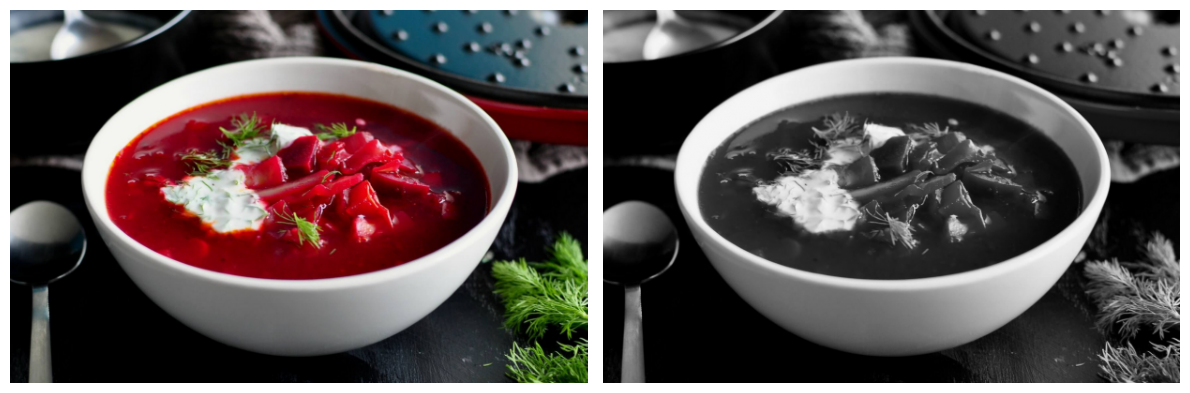

In [7]:
reload_solution_modules()

path = "borsh.png"
img = np.asarray(Image.open(path).convert("RGB"))
coefs = np.array([0.299, 0.587, 0.114])
conv_img = func_vec.convert_image(img, coefs)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(conv_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

plt.tight_layout()
plt.show()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

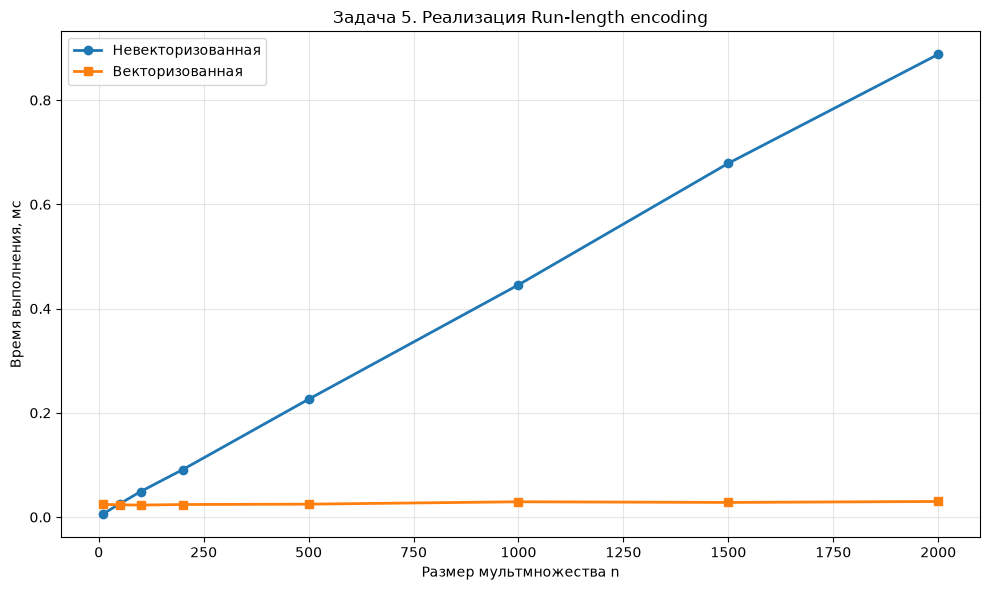

In [8]:
reload_solution_modules()
# code here

data_size = np.array([10, 50, 100, 200, 500, 1000, 1500, 2000])
rng = np.random.default_rng(2101)

n_runs = 100
n_repeats = 7

time_func = []
time_func_vec = []

for n in data_size:
    x = rng.integers(0, 100, size = (n), dtype = np.int64)

    cur_time_func = min(
        timeit.repeat(
            lambda: func.run_length_encoding(x),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_func_vec = min(
        timeit.repeat(
            lambda: func_vec.run_length_encoding(x),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    time_func.append(cur_time_func)
    time_func_vec.append(cur_time_func_vec)

plt.figure(figsize=(10, 6))

plt.plot(data_size, time_func,
         marker="o",
         linewidth=2,
         label="Невекторизованная")

plt.plot(data_size, time_func_vec,
         marker="s",
         linewidth=2,
         label="Векторизованная")

plt.title("Задача 5. Реализация Run-length encoding")
plt.xlabel("Размер мультмножества n")
plt.ylabel("Время выполнения, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

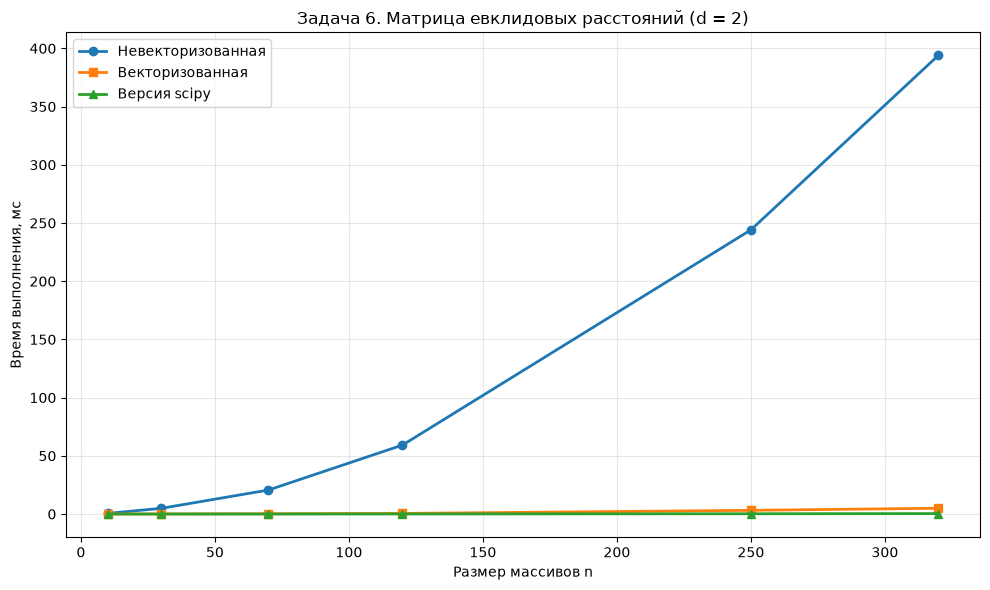

In [17]:
reload_solution_modules()
# code here

data_size = np.array([10, 30, 70, 120, 250, 320])
rng = np.random.default_rng(2101)

d = 2
n_runs = 10
n_repeats = 3

time_func = []
time_func_vec = []
time_scipy = []

for n in data_size:
    x = rng.integers(0, 100, size = (n, d), dtype = np.int64)
    y = rng.integers(0, 100, size = (n, d), dtype = np.int64)

    cur_time_func = min(
        timeit.repeat(
            lambda: func.pairwise_distance(x, y),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_func_vec = min(
        timeit.repeat(
            lambda: func_vec.pairwise_distance(x, y),
            number = n_runs,
            repeat = n_repeats
        )
    ) / n_runs * 1000

    cur_time_scipy = min(
        timeit.repeat(
            lambda: cdist(x, y),
            number=n_runs,
            repeat=n_repeats
        )
    ) / n_runs * 1000

    
    time_func.append(cur_time_func)
    time_func_vec.append(cur_time_func_vec)
    time_scipy.append(cur_time_scipy)

plt.figure(figsize=(10, 6))

plt.plot(data_size, time_func,
         marker="o",
         linewidth=2,
         label="Невекторизованная")

plt.plot(data_size, time_func_vec,
         marker="s",
         linewidth=2,
         label="Векторизованная")

plt.plot(data_size, time_scipy,
         marker="^", linewidth=2,
         label="Версия scipy")

plt.title("Задача 6. Матрица евклидовых расстояний (d = 2)")
plt.xlabel("Размер массивов n")
plt.ylabel("Время выполнения, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [8]:
# code here